In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "ndv[jupyter,vispy]",
#     "jupyter-rfb<=0.5.4",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [2]:
import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
from bobiac_tools import pixel_randomization
from scipy.stats import pearsonr

In [3]:
# open the image
img_path = "../../_static/images/coloc/t_cell.tif"
img = tifffile.imread(img_path)

In [ ]:
# visualize the image
ndv.imshow(img)

In [4]:
viewer = ndv.imshow(img)

RFBOutputContext()

<IPython.core.display.Javascript object>

RFBOutputContext()

RFBOutputContext()


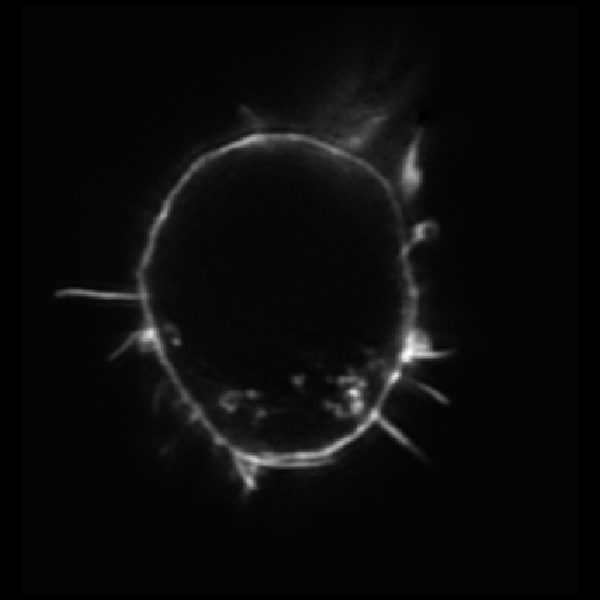

In [5]:
viewer.widget().children[1].snapshot()

In [6]:
# get image shape
print("Image shape:", img.shape)

Image shape: (2, 418, 393)


In [7]:
# split the image into channels
ch1 = img[0]
ch2 = img[1]

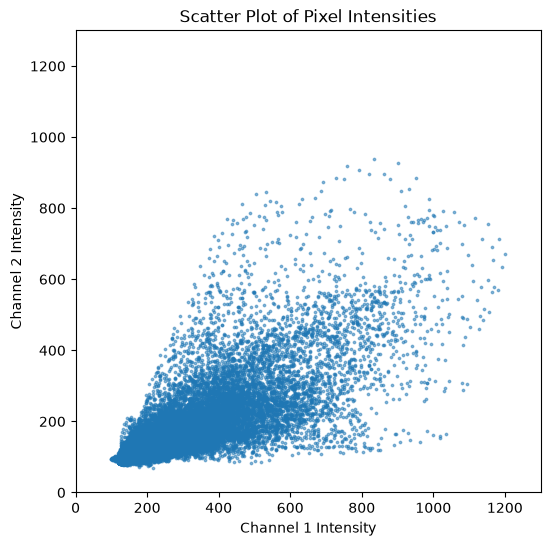

In [8]:
# plot scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(ch1.ravel(), ch2.ravel(), s=3, alpha=0.5)
plt.xlabel("Channel 1 Intensity")
plt.ylabel("Channel 2 Intensity")
plt.title("Scatter Plot of Pixel Intensities")
# set both axes to the same range based on the maximum value
max_intensity = max(ch1.max(), ch2.max()) + 100
plt.xlim(0, max_intensity)
plt.ylim(0, max_intensity)
plt.show()

In [9]:
mean_ch1 = np.mean(ch1)
mean_ch2 = np.mean(ch2)

numerator = np.sum((ch1 - mean_ch1) * (ch2 - mean_ch2))
denominator = np.sqrt(np.sum((ch1 - mean_ch1) ** 2) * np.sum((ch2 - mean_ch2) ** 2))
prs = numerator / denominator
print(f"Pearson's: {prs:.2}")

Pearson's: 0.84


In [10]:
# Calculate Pearson's correlation coefficient using scipy
pearson, p_value = pearsonr(ch1.ravel(), ch2.ravel())
print(f"Pearson's (scipy): {pearson:.2f}, p-value: {p_value:.4f}")
# Calculate Pearson's correlation coefficient using numpy
pearson_numpy = np.corrcoef(ch1.ravel(), ch2.ravel())[0, 1]
print(f"Pearson's (numpy): {pearson_numpy:.2f}")

Pearson's (scipy): 0.84, p-value: 0.0000
Pearson's (numpy): 0.84


In [11]:
pearson, random_corrs, p_value = pixel_randomization(ch1, ch2, n_iterations=100)
print(f"Observed Pearson's correlation: {pearson:.2f}, p-value: {p_value:.4f}\n")
# first 5 random correlations
print(random_corrs[:5])

Observed Pearson's correlation: 0.84, p-value: 0.0000

[0.001197200898056672, 0.002486536645632801, 0.002563280127592161, -0.002494077988106198, 0.002210413581187368]


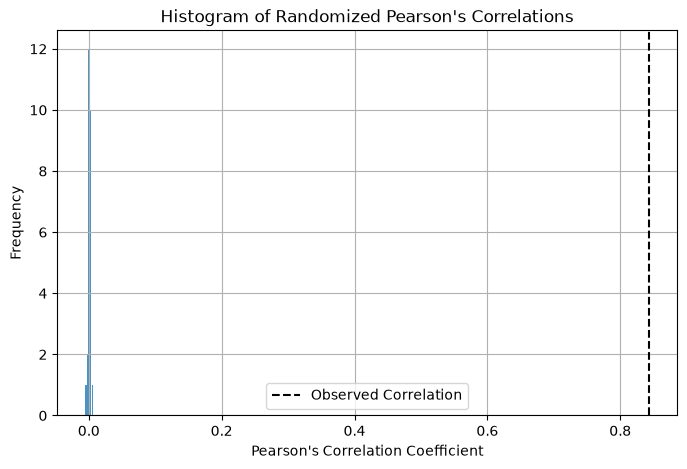

In [12]:
# plot histogram of random correlations
plt.figure(figsize=(8, 5))
plt.hist(random_corrs, bins=30, alpha=0.8)
plt.axvline(
    pearson, color="k", linestyle="dashed", linewidth=1.5, label="Observed Correlation"
)
plt.title("Histogram of Randomized Pearson's Correlations")
plt.xlabel("Pearson's Correlation Coefficient")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()